In [2]:
using JLD2
using PyPlot
using Statistics
using HDF5

In [4]:
using PyCall
pyimport_conda("skimage.measure", "scikit-image")

PyObject <module 'skimage.measure' from 'c:\\users\\joschka\\appdata\\local\\programs\\python\\python313\\Lib\\site-packages\\skimage\\measure\\__init__.py'>

<sys>:0: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


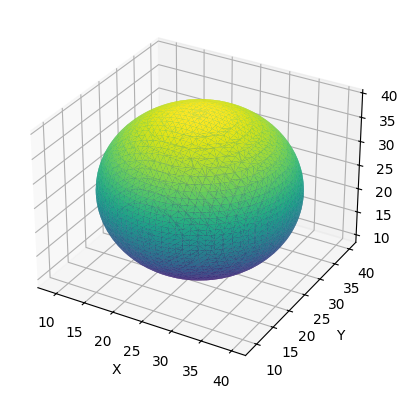

In [5]:
using PyPlot
using PyCall

# Import marching cubes from scikit-image
measure = pyimport("skimage.measure")

# Create a 3D grid
nx, ny, nz = 50, 50, 50
x = range(-2, 2, length=nx)
y = range(-2, 2, length=ny)
z = range(-2, 2, length=nz)

# Example density: 3D Gaussian
density = [exp(-(xi^2 + yi^2 + zi^2)) for xi in x, yi in y, zi in z]

# Compute isosurface
iso_value = 0.2
verts, faces, normals, values = measure.marching_cubes(density, iso_value)

# Plot
fig = figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(
    verts[:,1], verts[:,2], faces, verts[:,3],
    cmap="viridis", lw=1
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

show()

In [6]:
pathname_sim_julian = "Density_distributions/Groundstate_Bext_90_deg_as_98.h5"
file = h5open(pathname_sim_julian, "r")
n = read(file["n"])
nxy = read(file["nxy"])
nxz = read(file["nxz"])
x = read(file["x"])
y = read(file["y"])
z = read(file["z"])
dx, dy, dz = read(file["dx"])[1], read(file["dy"])[1], read(file["dz"])[1]
mask_xy = ((x.>-13) .* (x.<13))' * ((y.>-3) .* (y.<3))
mask_z = ((z.>-2) .* (z.<2))
mask_CS = mask_xy .* reshape(mask_z, 1, 1, length(mask_z))
n_CS = n .* mask_CS;

In [42]:
using PyPlot
using PyCall

# Import marching cubes from scikit-image
measure = pyimport("skimage.measure")

# Create a 3D gri

# Compute isosurface
iso_value = 0.2
verts, faces, normals, values = measure.marching_cubes(n, iso_value)
rc("font", size=12)
# Plot
fig = figure()
ax = fig.add_subplot(111, projection="3d")

# ax.set_position([0.0, 0.1, 0.5, 0.8])  

ax.plot_trisurf(
    verts[:,1]*dx .+x[1], verts[:,2]*dy .+y[1], faces, verts[:,3]*dz .+z[1],
    cmap="viridis", lw=1
)

ax.set_xlabel(L"x (in $\mu m$)")
ax.set_ylabel(L"y (in $\mu m$)")
ax.set_zlabel(L"z (in $\mu m$)")

factor_zoom = 2

ax.set_xlim(x[1]/factor_zoom, x[end]/factor_zoom)
ax.set_ylim(y[1]/factor_zoom, y[end]/factor_zoom)
ax.set_zlim(z[1]/factor_zoom, z[end]/factor_zoom)


# tight_layout() 
# fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
ax.grid(false)

# pygui(false)
pygui(true);show()

<sys>:0: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [44]:
@load "r0/Sat_0.1to40.1_n0_53.12/r0_N_30_density_idx_26_sat_40.1_n0_53.12.jdl2" r0 L

2-element Vector{Symbol}:
 :r0
 :L

In [53]:
@load "Density_distributions\\Groundstate_Bext_90_deg_as_98_N_30.jld2" CS_densities_cuts_norm

1-element Vector{Symbol}:
 :CS_densities_cuts_norm

In [59]:
CS_densities_cuts_norm[26]
n_list = CS_densities_cuts_norm[1:100:end]

26-element Vector{Float64}:
  0.06257766494692907
  4.954400476245195
 11.351003044071097
 16.54762818817203
 21.33600291869471
 25.147347117736796
 29.683217332335115
 36.328480085564685
 42.33513300427899
 46.27049233821197
 50.67917520284525
 55.50777375275046
 58.25339676663385
 61.2127558015676
 63.668246276928414
 65.47021541730187
 67.72971355012173
 69.78561324430385
 71.98111596951917
 76.20779416480424
 79.84344906347674
 82.72193280696241
 84.28867249361899
 85.72121747057854
 86.6560237536665
 87.47992098882136

In [60]:
n_list[26]

87.47992098882136

In [78]:
fig = figure()
ax = fig.add_subplot(111, projection="3d")

# 3D scatter
ax.scatter([r[1] for r in r0], [r[2] for r in r0], [r[3] for r in r0], c="blue", marker="o", s=50)  # s=size of points
ax.set_title(L"$n=$"*string(round(n_list[26], digits=1))*L" $\lambda^{-3}$")

# Labels
ax.set_xlabel(L"x/λ")
ax.set_ylabel(L"y/λ")
ax.set_zlabel(L"z/λ")

# Show plot
pygui(true); show()